# ✦ StudentLife Mood and Stress Output Analysis

## Finding the Minimum, Maximum, and Descriptive Statistics for Mood and Stress Scores

This notebook analyzes the mood and stress output variables for the sleep installation.

The goal is to understand the range of the emotional-state variables that can be used to control the installation atmosphere.

The two output variables are:

| Variable     | Source                        | Meaning in the installation                                    |
| ------------ | ----------------------------- | -------------------------------------------------------------- |
| mood_score   | StudentLife PAM picture_idx   | Controls visual mood, colour, warmth, and emotional atmosphere |
| stress_score | StudentLife Stress EMA or PSS | Controls soundscape tension, heartbeat, noise, and discomfort  |

These variables are based on self-reported student data, so they should be interpreted as mood and stress proxies rather than clinical measurements.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Find the main project folder.
# This is useful because this notebook is inside the Notebooks folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

# Main folders
DATA_DIR = PROJECT_DIR / "data"
STUDENTLIFE_DIR = DATA_DIR / "studentlife_rds"
GRAPH_DIR = PROJECT_DIR / "Graphs"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Current folder:", CURRENT_DIR)
print("Project folder:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("StudentLife folder:", STUDENTLIFE_DIR)
print("Graph folder:", GRAPH_DIR)

print("\nDoes StudentLife folder exist?")
print(STUDENTLIFE_DIR.exists())

Current folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Notebooks
Project folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis
Data folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data
StudentLife folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds
Graph folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs

Does StudentLife folder exist?
True


---

# 2. ✧ Finding the Mood and Stress Files

Before loading the mood and stress data, we first search the StudentLife dataset folder.

We are looking for files related to:

| Output       | Possible file keywords |
| ------------ | ---------------------- |
| mood_score   | PAM, mood, picture     |
| stress_score | stress, PSS, EMA       |

This step helps us confirm the exact filenames before creating the mood and stress variables.


In [2]:
# ------------------------------------------------------------
# Find possible StudentLife mood and stress files
# ------------------------------------------------------------

# Search from the whole data folder, because the exact extracted folder structure may vary
search_root = DATA_DIR

# Collect all files
all_files = list(search_root.rglob("*"))

# Keep only actual files
all_files = [file for file in all_files if file.is_file()]

print("Total files found in data folder:", len(all_files))

# Keywords that may identify mood and stress files
mood_keywords = ["pam", "mood", "picture"]
stress_keywords = ["stress", "pss"]

def find_matching_files(files, keywords):
    matches = []

    for file in files:
        file_text = str(file).lower()

        if any(keyword.lower() in file_text for keyword in keywords):
            matches.append(file)

    return matches

mood_matches = find_matching_files(all_files, mood_keywords)
stress_matches = find_matching_files(all_files, stress_keywords)

print("\nPossible mood-related files:")
print("----------------------------")
for file in mood_matches:
    print(file)

print("\nPossible stress-related files:")
print("------------------------------")
for file in stress_matches:
    print(file)

# Make a cleaner table for viewing
file_match_table = pd.DataFrame({
    "type": (
        ["possible mood file"] * len(mood_matches) +
        ["possible stress file"] * len(stress_matches)
    ),
    "file_path": (
        [str(file) for file in mood_matches] +
        [str(file) for file in stress_matches]
    )
})

display(file_match_table)

Total files found in data folder: 57

Possible mood-related files:
----------------------------
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Mood 1.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Mood 2.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Mood.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\PAM.Rds

Possible stress-related files:
------------------------------
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Stress.Rds
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\survey\PerceivedStressScale.Rds


,type,file_path
0,possible mood file,D:\Documentos\Sleep datasets\sleep_installatio...
1,possible mood file,D:\Documentos\Sleep datasets\sleep_installatio...
2,possible mood file,D:\Documentos\Sleep datasets\sleep_installatio...
3,possible mood file,D:\Documentos\Sleep datasets\sleep_installatio...
4,possible stress file,D:\Documentos\Sleep datasets\sleep_installatio...
5,possible stress file,D:\Documentos\Sleep datasets\sleep_installatio...


---

# 3. ✧ Loading and Inspecting the Mood and Stress Files

The file search found several possible mood and stress files.

For the installation, the most relevant files to inspect first are:

| Variable               | File                            |
| ---------------------- | ------------------------------- |
| mood_score             | EMA/PAM.Rds                     |
| stress_score           | EMA/Stress.Rds                  |
| possible stress backup | survey/PerceivedStressScale.Rds |

Before creating final variables, we inspect the columns and preview the data.

This helps us avoid guessing the wrong variable names.


In [3]:
# ------------------------------------------------------------
# Load and inspect the most relevant mood and stress files
# ------------------------------------------------------------

# If pyreadr is not installed, install it once with:
# !pip install pyreadr

try:
    import pyreadr
    print("pyreadr is ready.")
except ImportError:
    print("pyreadr is not installed yet.")
    print("Run this in a new code cell, then run this cell again:")
    print("!pip install pyreadr")

# File paths found in the previous step
pam_file = DATA_DIR / "studentlife_rds" / "dataset_rds" / "EMA" / "PAM.Rds"
stress_file = DATA_DIR / "studentlife_rds" / "dataset_rds" / "EMA" / "Stress.Rds"
pss_file = DATA_DIR / "studentlife_rds" / "dataset_rds" / "survey" / "PerceivedStressScale.Rds"

print("\nFiles we will inspect:")
print("PAM file exists:", pam_file.exists(), "-", pam_file)
print("Stress file exists:", stress_file.exists(), "-", stress_file)
print("PSS file exists:", pss_file.exists(), "-", pss_file)

def load_rds_file(file_path):
    result = pyreadr.read_r(str(file_path))

    # Most Rds files load with one unnamed object.
    # This takes the first object inside the file.
    data = list(result.values())[0]

    return data

# Load files
pam_df = load_rds_file(pam_file)
stress_df = load_rds_file(stress_file)
pss_df = load_rds_file(pss_file)

print("\nPAM data shape:")
print(pam_df.shape)
print("PAM columns:")
print(pam_df.columns.tolist())
display(pam_df.head())

print("\nStress EMA data shape:")
print(stress_df.shape)
print("Stress EMA columns:")
print(stress_df.columns.tolist())
display(stress_df.head())

print("\nPerceived Stress Scale data shape:")
print(pss_df.shape)
print("PSS columns:")
print(pss_df.columns.tolist())
display(pss_df.head())

pyreadr is ready.

Files we will inspect:
PAM file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\PAM.Rds
Stress file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Stress.Rds
PSS file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\survey\PerceivedStressScale.Rds

PAM data shape:
(9040, 3)
PAM columns:
['picture_idx', 'timestamp', 'uid']


,picture_idx,timestamp,uid
0,7.0,1.364115e+09,0
1,11.0,1.364156e+09,0
2,7.0,1.364114e+09,0
3,8.0,1.364115e+09,0
4,7.0,1.364264e+09,0



Stress EMA data shape:
(2017, 3)
Stress EMA columns:
['null', 'timestamp', 'uid']


,null,timestamp,uid
0,"43.75908069,-72.32885314",1.364114e+09,0
1,"43.75908069,-72.32885314",1.364114e+09,0
2,"43.70677151,-72.28746626",1.364178e+09,0
3,1,1.364170e+09,0
4,1,1.364178e+09,0



Perceived Stress Scale data shape:
(85, 12)
PSS columns:
['uid', 'type', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']


,uid,type,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,0,pre,Sometime,Sometime,Fairly often,Fairly often,Sometime,Very often,Sometime,Sometime,Fairly often,Fairly often
1,1,pre,Sometime,Sometime,Sometime,Sometime,Fairly often,Sometime,Fairly often,Fairly often,Almost never,Almost never
2,2,pre,Fairly often,Sometime,Sometime,Fairly often,Almost never,Sometime,Almost never,Sometime,Sometime,Almost never
3,3,pre,Sometime,Almost never,Sometime,Almost never,Sometime,Never,Almost never,Never,Never,Never
4,4,pre,Almost never,Almost never,Fairly often,Sometime,Sometime,Fairly often,Sometime,Almost never,Sometime,Sometime


---

# 4. ✧ Inspecting Mood and Stress Values More Carefully

The PAM file has a clear mood variable:

**picture_idx**

The Stress EMA file is less clear because its main response column is called:

**null**

Before creating the final mood_score and stress_score variables, we inspect the values more carefully.

We also inspect the Perceived Stress Scale file, which may be a cleaner source for stress.


In [4]:
# ------------------------------------------------------------
# Inspect mood and stress values more carefully
# ------------------------------------------------------------

print("PAM columns:")
print(pam_df.columns.tolist())

print("\nPAM basic information:")
display(pam_df.info())

print("\nPAM picture_idx descriptive statistics:")
display(pam_df["picture_idx"].describe())

print("\nPAM picture_idx value counts:")
display(
    pam_df["picture_idx"]
    .value_counts()
    .sort_index()
)

print("\n" + "="*70)

print("Stress EMA columns:")
print(stress_df.columns.tolist())

print("\nStress EMA basic information:")
display(stress_df.info())

print("\nStress EMA first 20 rows:")
display(stress_df.head(20))

print("\nStress EMA value counts for main response column:")
main_stress_column = stress_df.columns[0]

display(
    stress_df[main_stress_column]
    .value_counts(dropna=False)
    .head(30)
)

print("\n" + "="*70)

print("Perceived Stress Scale columns:")
print(pss_df.columns.tolist())

print("\nPerceived Stress Scale basic information:")
display(pss_df.info())

print("\nPerceived Stress Scale first 20 rows:")
display(pss_df.head(20))

print("\nPerceived Stress Scale descriptive statistics:")
display(pss_df.describe(include="all"))

PAM columns:
['picture_idx', 'timestamp', 'uid']

PAM basic information:
<class 'pandas.DataFrame'>
RangeIndex: 9040 entries, 0 to 9039
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   picture_idx  9040 non-null   float64 
 1   timestamp    9040 non-null   float64 
 2   uid          9040 non-null   category
dtypes: category(1), float64(2)
memory usage: 150.6 KB


None


PAM picture_idx descriptive statistics:


count    9040.000000
mean        8.846239
std         4.173686
min         1.000000
25%         6.000000
50%         8.000000
75%        12.000000
max        16.000000
Name: picture_idx, dtype: float64


PAM picture_idx value counts:


...

None


Perceived Stress Scale first 20 rows:


,uid,type,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,0,pre,Sometime,Sometime,Fairly often,Fairly often,Sometime,Very often,Sometime,Sometime,Fairly often,Fairly often
1,1,pre,Sometime,Sometime,Sometime,Sometime,Fairly often,Sometime,Fairly often,Fairly often,Almost never,Almost never
2,2,pre,Fairly often,Sometime,Sometime,Fairly often,Almost never,Sometime,Almost never,Sometime,Sometime,Almost never
3,3,pre,Sometime,Almost never,Sometime,Almost never,Sometime,Never,Almost never,Never,Never,Never
4,4,pre,Almost never,Almost never,Fairly often,Sometime,Sometime,Fairly often,Sometime,Almost never,Sometime,Sometime
5,5,pre,Almost never,Sometime,Almost never,Very often,Very often,Almost never,Fairly often,Very often,Almost never,Never
6,7,pre,Sometime,Almost never,Fairly often,Very often,Very often,Almost never,Fairly often,Fairly often,Sometime,Almost never
7,8,pre,Sometime,Fairly often,Very often,Sometime,Sometime,Sometime,Fairly often,Sometime,Sometime,Fairly often
8,9,pre,Almost never,Almost never,Sometime,Sometime,Fairly often,Almost never,Fairly often,Sometime,Almost never,Almost never
9,10,pre,Fairly often,Fairly often,Fairly often,Fairly often,Fairly often,Sometime,Almost never,Very often,Fairly often,Almost never



Perceived Stress Scale descriptive statistics:


,uid,type,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
count,85,85,85,85,84,85,84,85,85,85,85,85
unique,46,2,5,5,4,5,4,5,5,5,5,5
top,0,pre,Almost never,Sometime,Sometime,Fairly often,Sometime,Sometime,Fairly often,Sometime,Sometime,Almost never
freq,2,46,32,32,31,36,35,36,32,39,34,29


---

# 5. ✧ Creating Mood and Stress Output Variables

Now we create the two emotional output variables for the installation.

For mood, we use:

**picture_idx** from the PAM file.

In this notebook, we rename it to:

**mood_score**

For stress, we use the Perceived Stress Scale file.

The file contains ten questions:

**Q1 to Q10**

These questions are converted into numeric values and combined into:

**stress_raw**

Then stress_raw is scaled into:

**stress_score**

This gives us a stress output variable that can be used to control the soundscape tension, heartbeat, noise, and discomfort level in the installation.


In [5]:
# ------------------------------------------------------------
# Create mood_score from PAM picture_idx
# ------------------------------------------------------------

mood_analysis = pam_df[
    [
        "uid",
        "timestamp",
        "picture_idx"
    ]
].copy()

mood_analysis["mood_score"] = pd.to_numeric(
    mood_analysis["picture_idx"],
    errors="coerce"
)

mood_analysis = mood_analysis[
    mood_analysis["mood_score"].notna()
].copy()

print("Mood data created.")
print("Valid mood observations:", len(mood_analysis))

display(mood_analysis.head())


# ------------------------------------------------------------
# Create stress_score from Perceived Stress Scale
# ------------------------------------------------------------

pss_items = [
    "Q1", "Q2", "Q3", "Q4", "Q5",
    "Q6", "Q7", "Q8", "Q9", "Q10"
]

stress_analysis = pss_df[
    [
        "uid",
        "type"
    ] + pss_items
].copy()

# Convert text responses into numeric scores.
# Higher numbers mean higher stress before reverse scoring.
pss_response_map = {
    "Never": 0,
    "Almost never": 1,
    "Sometime": 2,
    "Sometimes": 2,
    "Fairly often": 3,
    "Very often": 4
}

for item in pss_items:
    stress_analysis[item + "_numeric"] = (
        stress_analysis[item]
        .astype(str)
        .str.strip()
        .map(pss_response_map)
    )

# Reverse-scored items in the Perceived Stress Scale
reverse_items = ["Q4", "Q5", "Q7", "Q8"]

for item in reverse_items:
    stress_analysis[item + "_numeric"] = 4 - stress_analysis[item + "_numeric"]

numeric_pss_items = [item + "_numeric" for item in pss_items]

print("\nMissing numeric PSS values:")
display(stress_analysis[numeric_pss_items].isna().sum())

# Keep only rows with complete stress data
stress_analysis = stress_analysis.dropna(
    subset=numeric_pss_items
).copy()

# Create raw stress score
stress_analysis["stress_raw"] = stress_analysis[numeric_pss_items].sum(axis=1)

# Scale stress score to 0–100
# PSS-10 raw score ranges from 0 to 40
STRESS_RAW_MAX = 40

stress_analysis["stress_score"] = (
    stress_analysis["stress_raw"] / STRESS_RAW_MAX
) * 100

print("\nStress data created.")
print("Valid stress survey entries:", len(stress_analysis))

display(
    stress_analysis[
        [
            "uid",
            "type",
            "stress_raw",
            "stress_score"
        ]
    ].head()
)

Mood data created.
Valid mood observations: 9040


,uid,timestamp,picture_idx,mood_score
0,0,1.364115e+09,7.0,7.0
1,0,1.364156e+09,11.0,11.0
2,0,1.364114e+09,7.0,7.0
3,0,1.364115e+09,8.0,8.0
4,0,1.364264e+09,7.0,7.0



Missing numeric PSS values:


Q1_numeric     0
Q2_numeric     0
Q3_numeric     1
Q4_numeric     0
Q5_numeric     1
Q6_numeric     0
Q7_numeric     0
Q8_numeric     0
Q9_numeric     0
Q10_numeric    0
dtype: int64


Stress data created.
Valid stress survey entries: 83


,uid,type,stress_raw,stress_score
0,0,pre,24.0,60.0
1,1,pre,15.0,37.5
2,2,pre,21.0,52.5
3,3,pre,17.0,42.5
4,4,pre,21.0,52.5


---

# 6. ✧ Describing the Mood and Stress Output Variables

Now we calculate descriptive statistics for the emotional output variables.

For mood, we describe:

**mood_score**

This comes from the PAM picture index.

For stress, we describe two variables:

| Variable     | Meaning                                            |
| ------------ | -------------------------------------------------- |
| stress_raw   | Combined Perceived Stress Scale score from 0 to 40 |
| stress_score | Stress score scaled from 0 to 100                  |

The stress_score variable is easier to use in the installation because it gives a clear output range for controlling soundscape tension, heartbeat, noise, and discomfort.


In [6]:
# ------------------------------------------------------------
# Descriptive statistics for mood_score
# ------------------------------------------------------------

mood_score = mood_analysis["mood_score"].dropna()

mood_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(mood_score.count())} observations",
        f"{mood_score.min():.2f}",
        f"{mood_score.quantile(0.25):.2f}",
        f"{mood_score.median():.2f}",
        f"{mood_score.mean():.2f}",
        f"{mood_score.quantile(0.75):.2f}",
        f"{mood_score.max():.2f}",
        f"{mood_score.std():.2f}"
    ],
    "Simple meaning": [
        "Number of valid mood observations analyzed",
        "Lowest PAM picture index",
        "25% of observations were at or below this value",
        "Middle PAM picture index",
        "Average PAM picture index",
        "75% of observations were at or below this value",
        "Highest PAM picture index",
        "How spread out the mood proxy values are"
    ]
})

print("Mood output descriptive statistics")
print("----------------------------------")
display(mood_stats_table)

print("\nFull numeric mood descriptive statistics:")
display(mood_score.describe())


# ------------------------------------------------------------
# Descriptive statistics for stress_raw and stress_score
# ------------------------------------------------------------

stress_raw = stress_analysis["stress_raw"].dropna()
stress_score = stress_analysis["stress_score"].dropna()

stress_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "stress_raw": [
        f"{int(stress_raw.count())} survey entries",
        f"{stress_raw.min():.2f}",
        f"{stress_raw.quantile(0.25):.2f}",
        f"{stress_raw.median():.2f}",
        f"{stress_raw.mean():.2f}",
        f"{stress_raw.quantile(0.75):.2f}",
        f"{stress_raw.max():.2f}",
        f"{stress_raw.std():.2f}"
    ],
    "stress_score": [
        f"{int(stress_score.count())} survey entries",
        f"{stress_score.min():.2f}",
        f"{stress_score.quantile(0.25):.2f}",
        f"{stress_score.median():.2f}",
        f"{stress_score.mean():.2f}",
        f"{stress_score.quantile(0.75):.2f}",
        f"{stress_score.max():.2f}",
        f"{stress_score.std():.2f}"
    ],
    "Simple meaning": [
        "Number of valid stress survey entries analyzed",
        "Lowest stress result",
        "25% of stress entries were at or below this value",
        "Middle stress result",
        "Average stress result",
        "75% of stress entries were at or below this value",
        "Highest stress result",
        "How spread out the stress results are"
    ]
})

print("\nStress output descriptive statistics")
print("------------------------------------")
display(stress_stats_table)

print("\nFull numeric stress descriptive statistics:")
display(
    stress_analysis[
        [
            "stress_raw",
            "stress_score"
        ]
    ].describe()
)

Mood output descriptive statistics
----------------------------------


,Statistic,Value,Simple meaning
0,Count,9040 observations,Number of valid mood observations analyzed
1,Minimum,1.00,Lowest PAM picture index
2,25th percentile,6.00,25% of observations were at or below this value
3,Median,8.00,Middle PAM picture index
4,Mean,8.85,Average PAM picture index
5,75th percentile,12.00,75% of observations were at or below this value
6,Maximum,16.00,Highest PAM picture index
7,Standard deviation,4.17,How spread out the mood proxy values are



Full numeric mood descriptive statistics:


count    9040.000000
mean        8.846239
std         4.173686
min         1.000000
25%         6.000000
50%         8.000000
75%        12.000000
max        16.000000
Name: mood_score, dtype: float64


Stress output descriptive statistics
------------------------------------


,Statistic,stress_raw,stress_score,Simple meaning
0,Count,83 survey entries,83 survey entries,Number of valid stress survey entries analyzed
1,Minimum,3.00,7.50,Lowest stress result
2,25th percentile,14.00,35.00,25% of stress entries were at or below this value
3,Median,18.00,45.00,Middle stress result
4,Mean,18.40,45.99,Average stress result
5,75th percentile,23.00,57.50,75% of stress entries were at or below this value
6,Maximum,34.00,85.00,Highest stress result
7,Standard deviation,6.98,17.45,How spread out the stress results are



Full numeric stress descriptive statistics:


,stress_raw,stress_score
count,83.000000,83.000000
mean,18.397590,45.993976
std,6.978957,17.447394
min,3.000000,7.500000
25%,14.000000,35.000000
50%,18.000000,45.000000
75%,23.000000,57.500000
max,34.000000,85.000000


---

# 7. ✧ Inspecting the Explicit Mood Files

The PAM file only gives a picture index.

Because we do not yet have the mapping from picture index to emotional meaning, we now inspect the other StudentLife mood files.

These files may contain more directly interpretable mood responses.

We inspect:

| File       | Reason                       |
| ---------- | ---------------------------- |
| Mood.Rds   | Possible explicit mood EMA   |
| Mood 1.Rds | Possible additional mood EMA |
| Mood 2.Rds | Possible additional mood EMA |

If one of these files has clearer emotional labels, it may be better for the installation than PAM picture_idx.


In [9]:
# ------------------------------------------------------------
# Load and inspect explicit mood files
# ------------------------------------------------------------

mood_file = DATA_DIR / "studentlife_rds" / "dataset_rds" / "EMA" / "Mood.Rds"
mood1_file = DATA_DIR / "studentlife_rds" / "dataset_rds" / "EMA" / "Mood 1.Rds"
mood2_file = DATA_DIR / "studentlife_rds" / "dataset_rds" / "EMA" / "Mood 2.Rds"

print("Mood file exists:", mood_file.exists(), "-", mood_file)
print("Mood 1 file exists:", mood1_file.exists(), "-", mood1_file)
print("Mood 2 file exists:", mood2_file.exists(), "-", mood2_file)

mood_direct_df = load_rds_file(mood_file)
mood1_df = load_rds_file(mood1_file)
mood2_df = load_rds_file(mood2_file)

print("\n" + "="*70)
print("Mood.Rds")
print("Shape:", mood_direct_df.shape)
print("Columns:", mood_direct_df.columns.tolist())
display(mood_direct_df.head(20))
display(mood_direct_df.describe(include="all"))

print("\n" + "="*70)
print("Mood 1.Rds")
print("Shape:", mood1_df.shape)
print("Columns:", mood1_df.columns.tolist())
display(mood1_df.head(20))
display(mood1_df.describe(include="all"))

print("\n" + "="*70)
print("Mood 2.Rds")
print("Shape:", mood2_df.shape)
print("Columns:", mood2_df.columns.tolist())
display(mood2_df.head(20))
display(mood2_df.describe(include="all"))

Mood file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Mood.Rds
Mood 1 file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Mood 1.Rds
Mood 2 file exists: True - D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds\EMA\Mood 2.Rds

Mood.Rds
Shape: (277, 7)
Columns: ['happy', 'happyornot', 'location', 'timestamp', 'sad', 'sadornot', 'uid']


,happy,happyornot,location,timestamp,sad,sadornot,uid
0,1.0,2,"43.75921839,-72.32919741",1.366870e+09,3.0,1,0
1,2.0,1,Unknown,1.366858e+09,4.0,1,0
2,2.0,1,"43.71332016,-72.30876457",1.368719e+09,1.0,1,0
3,3.0,1,"43.75880824,-72.32925862",1.368631e+09,1.0,2,0
4,2.0,1,"43.75929012,-72.32904032",1.368803e+09,1.0,null,0
5,1.0,null,"43.75906255,-72.32936718",1.369104e+09,1.0,null,0
6,1.0,2,"43.70685166,-72.28720734",1.369195e+09,1.0,2,0
7,1.0,1,"43.7065519,-72.28701015",1.369277e+09,1.0,1,0
8,1.0,null,"43.70206745,-72.2892032",1.375840e+09,1.0,null,0
9,1.0,null,"43.70579481,-72.28577693",1.376106e+09,1.0,null,0


,happy,happyornot,location,timestamp,sad,sadornot,uid
count,276.000000,277,276,2.770000e+02,276.000000,276,277
unique,NaN,3,221,NaN,NaN,3,38
top,NaN,1,Unknown,NaN,NaN,1,59
freq,NaN,229,40,NaN,NaN,142,83
mean,1.865942,NaN,NaN,1.368556e+09,1.373188,NaN,NaN
std,0.926459,NaN,NaN,1.191026e+06,0.810301,NaN,NaN
min,1.000000,NaN,NaN,1.366845e+09,1.000000,NaN,NaN
25%,1.000000,NaN,NaN,1.367720e+09,1.000000,NaN,NaN
50%,2.000000,NaN,NaN,1.368684e+09,1.000000,NaN,NaN
75%,3.000000,NaN,NaN,1.369210e+09,1.000000,NaN,NaN



Mood 1.Rds
Shape: (270, 4)
Columns: ['location', 'timestamp', 'tomorrow', 'uid']


,location,timestamp,tomorrow,uid
0,"43.7069422,-72.28679881",1.366931e+09,2.0,0
1,"43.70674491,-72.28743434",1.367377e+09,3.0,0
2,"43.66395962,-72.24163402",1.367625e+09,1.0,0
3,Unknown,1.367625e+09,1.0,0
4,Unknown,1.369891e+09,1.0,0
5,"43.75915222,-72.32954385",1.369720e+09,1.0,0
6,"43.75929059,-72.32919777",1.369629e+09,1.0,0
7,"43.70434788,-72.28657033",1.369803e+09,1.0,0
8,"43.70647159,-72.28748884",1.369976e+09,1.0,0
9,"43.75936117,-72.32975719",1.370149e+09,1.0,0


,location,timestamp,tomorrow,uid
count,270,2.700000e+02,270.000000,270
unique,221,NaN,NaN,40
top,Unknown,NaN,NaN,59
freq,42,NaN,NaN,49
mean,NaN,1.368523e+09,1.837037,NaN
std,NaN,1.321213e+06,0.796903,NaN
min,NaN,1.366851e+09,1.000000,NaN
25%,NaN,1.367377e+09,1.000000,NaN
50%,NaN,1.368184e+09,2.000000,NaN
75%,NaN,1.369798e+09,2.000000,NaN



Mood 2.Rds
Shape: (131, 5)
Columns: ['how', 'location', 'null', 'timestamp', 'uid']


,how,location,null,timestamp,uid
0,NaN,NaN,"43.70673326,-72.28908826",1.366879e+09,1
1,1.0,"43.7034112,-72.28787142",NaN,1.367020e+09,1
2,1.0,"43.70143085,-72.28787164",NaN,1.368143e+09,1
3,NaN,NaN,3,1.366851e+09,8
4,2.0,"43.70354857,-72.28679727",NaN,1.366927e+09,8
5,2.0,"43.70295661,-72.28995533",NaN,1.367023e+09,8
6,1.0,"43.70708811,-72.28767562",NaN,1.367400e+09,8
7,2.0,"43.7037094,-72.28660102",NaN,1.367746e+09,8
8,3.0,"43.7049437,-72.28880281",NaN,1.367899e+09,8
9,3.0,"43.70606871,-72.28870134",NaN,1.368053e+09,8


,how,location,null,timestamp,uid
count,124.000000,124,7,1.310000e+02,131
unique,NaN,85,5,NaN,5
top,NaN,Unknown,3,NaN,59
freq,NaN,32,3,NaN,100
mean,1.903226,NaN,NaN,1.368549e+09,NaN
std,0.905443,NaN,NaN,1.176287e+06,NaN
min,1.000000,NaN,NaN,1.366845e+09,NaN
25%,1.000000,NaN,NaN,1.367528e+09,NaN
50%,2.000000,NaN,NaN,1.368230e+09,NaN
75%,3.000000,NaN,NaN,1.369691e+09,NaN


---

# 8. ✧ Creating an Interpretable Mood Score

The PAM file only gives a picture index, and the emotional meaning of each picture index is not available in the extracted dataset.

Therefore, we do not use PAM as the final mood output variable.

Instead, we use the explicit Mood.Rds file.

This file contains two directly interpretable emotional variables:

| Variable | Meaning                        |
| -------- | ------------------------------ |
| happy    | How happy the participant felt |
| sad      | How sad the participant felt   |

Both variables range from 1 to 4.

To create one installation-friendly mood score, we combine happiness and sadness into a mood balance score:

**mood_score = ((happy - sad + 3) / 6) × 100**

This creates a 0–100 mood score:

| Score range  | Installation meaning                       |
| ------------ | ------------------------------------------ |
| Low score    | More sad / darker emotional atmosphere     |
| Middle score | More neutral or mixed emotional atmosphere |
| High score   | More happy / warmer emotional atmosphere   |

This mood_score is easier to map onto colour, warmth, facial expression, and visual atmosphere.


In [10]:
# ------------------------------------------------------------
# Create interpretable mood_score from Mood.Rds
# ------------------------------------------------------------

# Use the explicit mood file instead of PAM
mood_interpretable = mood_direct_df[
    [
        "uid",
        "timestamp",
        "happy",
        "sad"
    ]
].copy()

# Convert happy and sad to numeric
mood_interpretable["happy"] = pd.to_numeric(
    mood_interpretable["happy"],
    errors="coerce"
)

mood_interpretable["sad"] = pd.to_numeric(
    mood_interpretable["sad"],
    errors="coerce"
)

print("Missing values before keeping complete mood cases:")
display(mood_interpretable[["happy", "sad"]].isna().sum())

# Keep rows where both happy and sad are available
mood_interpretable = mood_interpretable.dropna(
    subset=["happy", "sad"]
).copy()

# Create 0-100 mood score
# happy - sad ranges from -3 to +3
# adding 3 shifts it to 0-6
# dividing by 6 scales it to 0-1
# multiplying by 100 makes it 0-100
mood_interpretable["mood_score"] = (
    (mood_interpretable["happy"] - mood_interpretable["sad"] + 3) / 6
) * 100

print("Interpretable mood data created.")
print("Valid mood observations:", len(mood_interpretable))

display(
    mood_interpretable[
        [
            "uid",
            "timestamp",
            "happy",
            "sad",
            "mood_score"
        ]
    ].head()
)

print("\nMood score descriptive statistics:")
display(mood_interpretable["mood_score"].describe())

Missing values before keeping complete mood cases:


happy    1
sad      1
dtype: int64

Interpretable mood data created.
Valid mood observations: 276


,uid,timestamp,happy,sad,mood_score
0,0,1.366870e+09,1.0,3.0,16.666667
1,0,1.366858e+09,2.0,4.0,16.666667
2,0,1.368719e+09,2.0,1.0,66.666667
3,0,1.368631e+09,3.0,1.0,83.333333
4,0,1.368803e+09,2.0,1.0,66.666667



Mood score descriptive statistics:


count    276.000000
mean      58.212560
std       23.376270
min        0.000000
25%       50.000000
50%       66.666667
75%       66.666667
max      100.000000
Name: mood_score, dtype: float64

---

# 9. ✧ Describing the Interpretable Mood Score

Now we create a clear descriptive statistics table for the final mood output variable.

The final mood variable is:

**mood_score**

This score is created from the balance between happiness and sadness:

**mood_score = ((happy - sad + 3) / 6) × 100**

The score ranges from 0 to 100.

Lower scores represent a sadder emotional atmosphere.

Middle scores represent a more neutral or mixed emotional atmosphere.

Higher scores represent a happier emotional atmosphere.


In [11]:
# ------------------------------------------------------------
# Descriptive statistics for final interpretable mood_score
# ------------------------------------------------------------

mood_score = mood_interpretable["mood_score"].dropna()

print("Final mood_score descriptive statistics")
print("---------------------------------------")
print("Valid observations:", len(mood_score))
print("Minimum:", round(mood_score.min(), 2))
print("Maximum:", round(mood_score.max(), 2))
print("Mean:", round(mood_score.mean(), 2))
print("Median:", round(mood_score.median(), 2))
print("Standard deviation:", round(mood_score.std(), 2))

# Create a clean table for display
mood_interpretable_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(mood_score.count())} observations",
        f"{mood_score.min():.2f}",
        f"{mood_score.quantile(0.25):.2f}",
        f"{mood_score.median():.2f}",
        f"{mood_score.mean():.2f}",
        f"{mood_score.quantile(0.75):.2f}",
        f"{mood_score.max():.2f}",
        f"{mood_score.std():.2f}"
    ],
    "Simple meaning": [
        "Number of valid mood observations analyzed",
        "Lowest mood score",
        "25% of observations were at or below this value",
        "Middle mood score",
        "Average mood score",
        "75% of observations were at or below this value",
        "Highest mood score",
        "How spread out the mood scores are"
    ]
})

display(mood_interpretable_stats_table)

print("\nFull numeric descriptive statistics:")
print(mood_score.describe().to_string())

Final mood_score descriptive statistics
---------------------------------------
Valid observations: 276
Minimum: 0.0
Maximum: 100.0
Mean: 58.21
Median: 66.67
Standard deviation: 23.38


,Statistic,Value,Simple meaning
0,Count,276 observations,Number of valid mood observations analyzed
1,Minimum,0.00,Lowest mood score
2,25th percentile,50.00,25% of observations were at or below this value
3,Median,66.67,Middle mood score
4,Mean,58.21,Average mood score
5,75th percentile,66.67,75% of observations were at or below this value
6,Maximum,100.00,Highest mood score
7,Standard deviation,23.38,How spread out the mood scores are



Full numeric descriptive statistics:
count    276.000000
mean      58.212560
std       23.376270
min        0.000000
25%       50.000000
50%       66.666667
75%       66.666667
max      100.000000


---

# 10. ✧ Graphing Mood and Stress Output Distributions

Now we create distribution graphs for the two emotional output variables.

The first graph shows:

**mood_score**

The second graph shows:

**stress_score**

Both variables are scaled from 0 to 100.

These graphs help show the emotional range that the installation can map onto visual atmosphere and soundscape intensity.


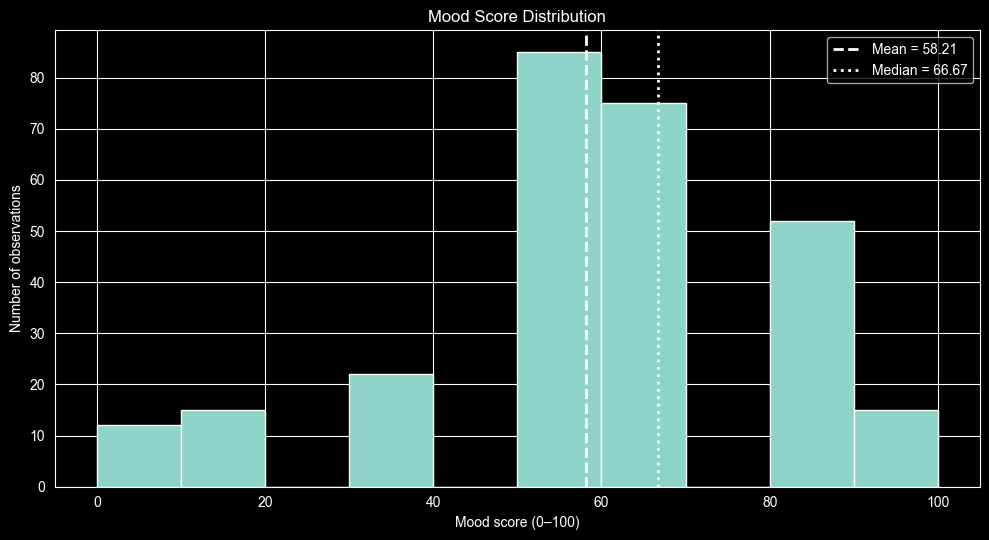

Mood graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\mood_score_distribution.png


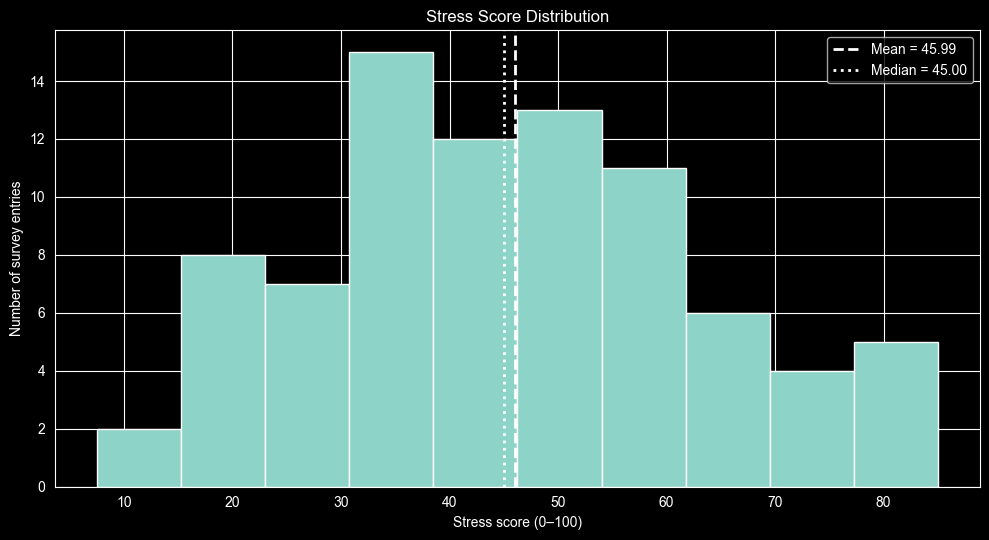

Stress graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\stress_score_distribution.png


In [12]:
# ------------------------------------------------------------
# Graph mood_score and stress_score distributions
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Select values
mood_score = mood_interpretable["mood_score"].dropna()
stress_score = stress_analysis["stress_score"].dropna()


# ------------------------------------------------------------
# Graph 1: Mood score distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.5))

plt.hist(mood_score, bins=10)

plt.axvline(
    mood_score.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mood_score.mean():.2f}"
)

plt.axvline(
    mood_score.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {mood_score.median():.2f}"
)

plt.title("Mood Score Distribution")
plt.xlabel("Mood score (0–100)")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()

mood_graph_path = GRAPH_DIR / "mood_score_distribution.png"
plt.savefig(mood_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Mood graph saved to:")
print(mood_graph_path)


# ------------------------------------------------------------
# Graph 2: Stress score distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.5))

plt.hist(stress_score, bins=10)

plt.axvline(
    stress_score.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {stress_score.mean():.2f}"
)

plt.axvline(
    stress_score.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {stress_score.median():.2f}"
)

plt.title("Stress Score Distribution")
plt.xlabel("Stress score (0–100)")
plt.ylabel("Number of survey entries")
plt.legend()
plt.tight_layout()

stress_graph_path = GRAPH_DIR / "stress_score_distribution.png"
plt.savefig(stress_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Stress graph saved to:")
print(stress_graph_path)